In [59]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [61]:
import tensorflow as tf
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()
#or
#(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data(path="mnist.npz")
print(X_train.shape)
print(X_test.shape)

print(Y_train.shape)
print(Y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [63]:
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(X_train.shape)
print(X_test.shape)

print(Y_train.shape)
print(Y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


[[1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]]


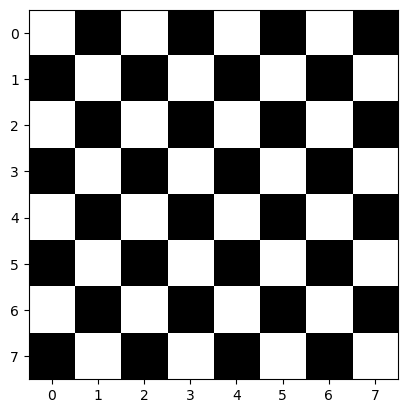

In [65]:
import numpy as np
import matplotlib.pyplot as plt
 
# create a 8x8 matrix of two numbers-0 and 1. 
arr=np.array([[1,0]*4,[0,1]*4]*4)
print(arr)

# use the imshow function to display the image made from the above array
plt.imshow(arr, cmap="gray")

(480, 640, 3)


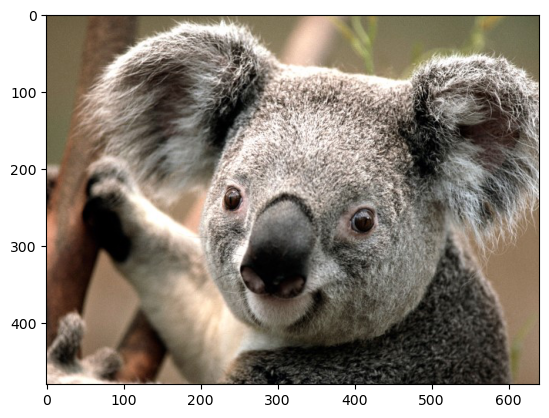

In [67]:
import matplotlib.pyplot as plt
# read the image
pix=plt.imread("./images/koala.jpg")
#display the shape of image data
print(pix.shape)
#print(pix)
#display the image
plt.imshow(pix)

(443, 590, 3)


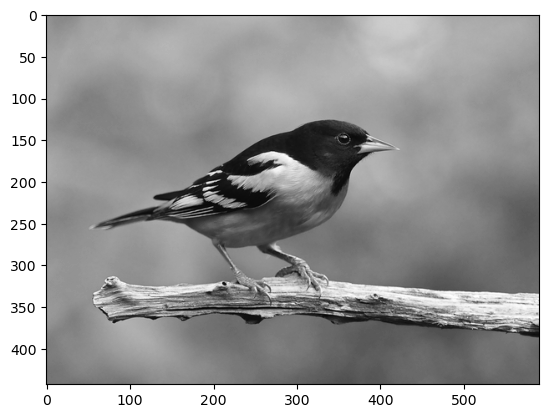

In [69]:
import matplotlib.pyplot as plt

# load the image
pix= plt.imread("./images/bird.png")

#display the shape of image data
print(pix.shape)

#display the grey scale image
plt.imshow(pix[: , :, 1] , cmap='gray')


In [71]:
import tensorflow as tf
rank_4_tensor = tf.zeros([3, 2, 4, 5])

print("Type of every element:", rank_4_tensor.dtype)
print("Number of axes:", rank_4_tensor.ndim)
print("Shape of tensor:", rank_4_tensor.shape)
print("Elements along axis 0 of tensor:", rank_4_tensor.shape[0])
print("Elements along the last axis of tensor:", rank_4_tensor.shape[-1])
print("Total number of elements (3*2*4*5): ", tf.size(rank_4_tensor).numpy())

Type of every element: <dtype: 'float32'>
Number of axes: 4
Shape of tensor: (3, 2, 4, 5)
Elements along axis 0 of tensor: 3
Elements along the last axis of tensor: 5
Total number of elements (3*2*4*5):  120


In [73]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [75]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [77]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [79]:
# Load the data from mnist dataset

(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()

# Reshape to tensors format

train_images = X_train.reshape(60000, 28, 28, 1)
test_images = X_test.reshape(10000, 28, 28, 1)

train_labels1 = Y_train.reshape(60000, 1)
test_labels1 = Y_test.reshape(10000, 1)

# Display the tensor shape of train images

print(train_images.size)
print(train_images.ndim)
print(train_images.shape)
print(train_images.shape[0])
print(train_images.shape[-1])


47040000
4
(60000, 28, 28, 1)
60000
1


In [81]:
train_labels = to_categorical(Y_train, 10)
test_labels = to_categorical(Y_test, 10)
print(train_labels.shape)

(60000, 10)


In [83]:
train_images, test_images = train_images / 255.0, test_images / 255.0

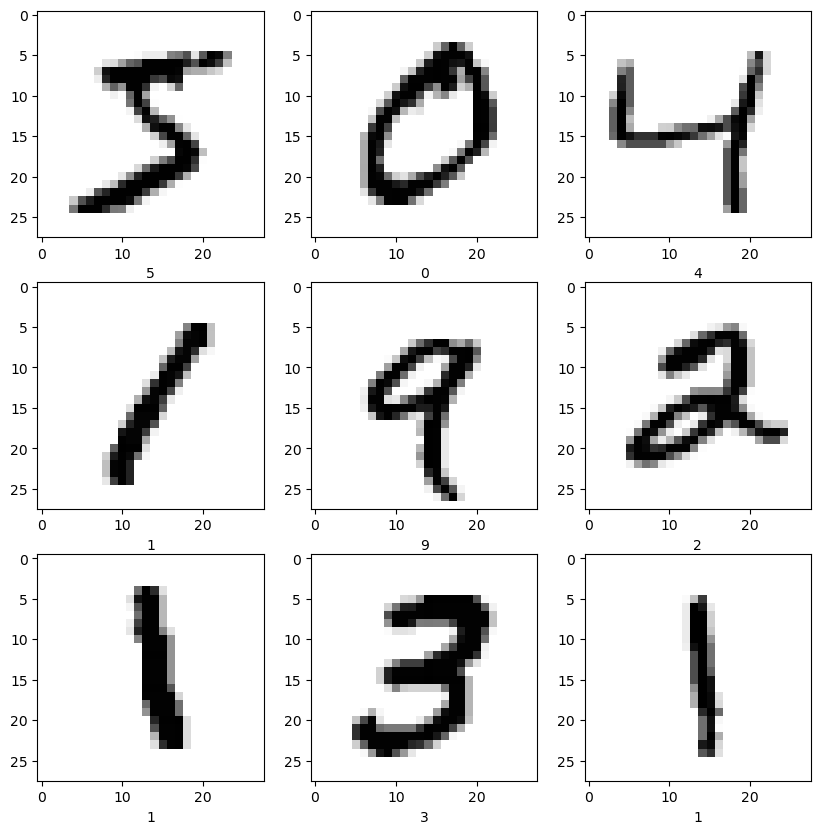

In [85]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)    
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels1[i][0]])
plt.show()

In [87]:
model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(28, 28, 1)))
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 24, 24, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │         294,976 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 305,194 (1.16 MB)

 Trainable params: 305,194 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [89]:
model.compile(loss=tf.keras.losses.categorical_crossentropy, metrics=['accuracy'], optimizer='adam')

In [91]:
history = model.fit(train_images, train_labels, epochs=10, batch_size=100, validation_data=(test_images, test_labels))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.8841 - loss: 0.3945 - val_accuracy: 0.9795 - val_loss: 0.0663
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.9821 - loss: 0.0600 - val_accuracy: 0.9842 - val_loss: 0.0501
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9882 - loss: 0.0376 - val_accuracy: 0.9859 - val_loss: 0.0389
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9928 - loss: 0.0225 - val_accuracy: 0.9874 - val_loss: 0.0386
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9938 - loss: 0.0196 - val_accuracy: 0.9877 - val_loss: 0.0387
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.9960 - loss: 0.0129 - val_accuracy: 0.9879 - val_loss: 0.0400
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9967 - loss: 0.0094 - val_accuracy: 0.9839 - val_loss: 0.0629
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9970 - loss: 0.0091 - 

In [93]:
# Evaluate the model
scores = model.evaluate(test_images, test_labels, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Accuracy: 98.89%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
This image most likely belongs to 4 with a 100.00 percent confidence.


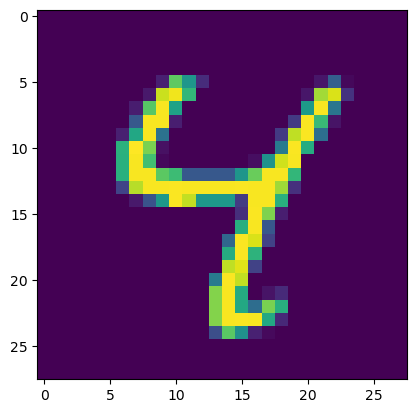

In [95]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

predict = model.predict(test_images[:10])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(predict[6])], 100 * np.max(predict))
)

# The original image
plt.imshow(test_images[6])

In [125]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [151]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [153]:
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.fashion_mnist.load_data()

train_images = X_train.reshape(60000, 28, 28, 1)
test_images = X_test.reshape(10000, 28, 28, 1)

train_labels = Y_train.reshape(60000, 1)
test_labels = Y_test.reshape(10000, 1)

print(train_images.size)
print(train_images.ndim)
print(train_images.shape)
print(train_images.shape[0])
print(train_images.shape[-1])

print(train_labels.shape)

47040000
4
(60000, 28, 28, 1)
60000
1
(60000, 1)


In [155]:
train_images, test_images = train_images / 255.0, test_images / 255.0

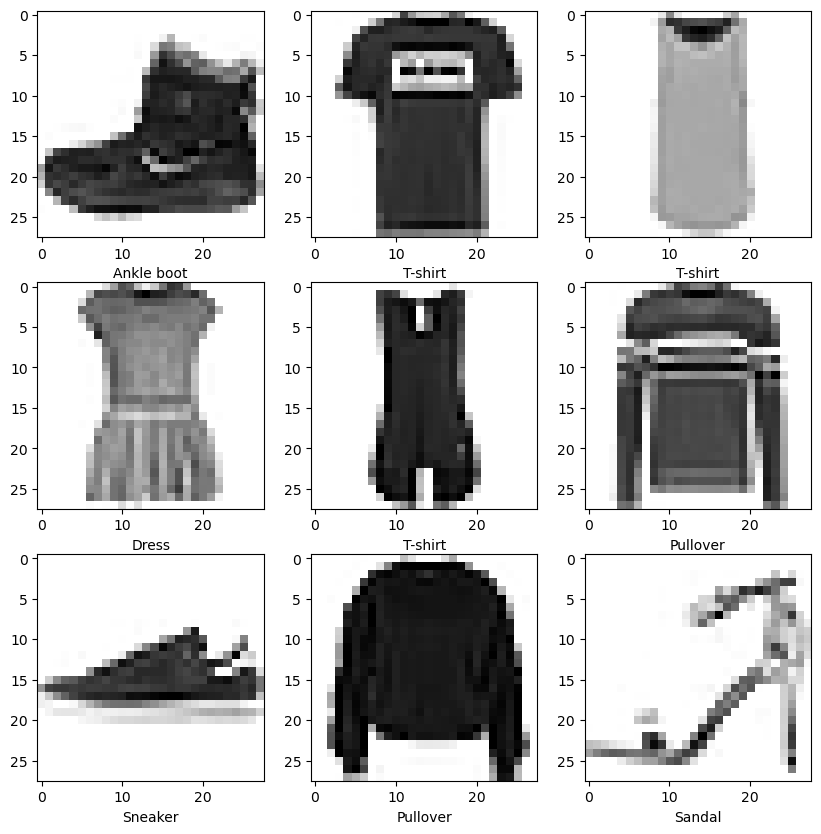

In [159]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)    
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i][0]])

plt.show()

In [169]:
model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(28, 28, 1)))
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

print(model.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)                   │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │         589,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 609,354 (2.32 MB)

 Trainable params: 609,354 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

None


In [171]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy, metrics=['accuracy'], optimizer='adam')

In [175]:
history = model.fit(train_images, train_labels, epochs=10, batch_size=100, validation_data=(test_images, test_labels))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.7804 - loss: 0.6183 - val_accuracy: 0.8837 - val_loss: 0.3277
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.8986 - loss: 0.2824 - val_accuracy: 0.9052 - val_loss: 0.2593
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.9156 - loss: 0.2282 - val_accuracy: 0.9086 - val_loss: 0.2455
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.9318 - loss: 0.1877 - val_accuracy: 0.9042 - val_loss: 0.2670
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.9419 - loss: 0.1590 - val_accuracy: 0.9188 - val_loss: 0.2283
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.9530 - loss: 0.1318 - val_accuracy: 0.9168 - val_loss: 0.2498
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.9582 - loss: 0.1131 - val_accuracy: 0.9231 - val_loss: 0.2446
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9665 - loss: 0.0900 - 

In [177]:
# Evaluate the model
scores = model.evaluate(test_images, test_labels, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Accuracy: 92.19%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
This image most likely belongs to Trouser with a 100.00 percent confidence.


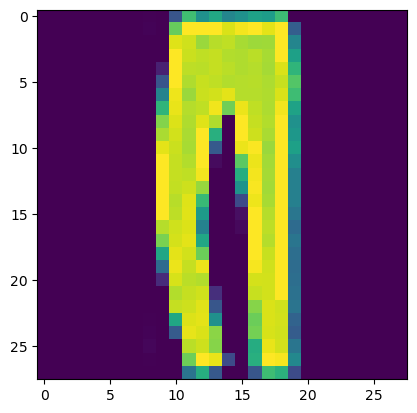

In [199]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

predict = model.predict(test_images[:10])

print(
   "This image most likely belongs to {} with a {:.2f} percent confidence."
   .format(class_names[np.argmax(predict[2])], 100 * np.max(predict))
)

# The original image
plt.imshow(test_images[2])